In [2]:
# Cell 1 - Project Setup and Data Generation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print("""
╔══════════════════════════════════════════════════════════════╗
║       NORTHERNBANK — PRIMEBANK ACQUISITION                   ║
║       Data Migration Intelligence System                     ║
║       Phase 1: Data Profiling and Quality Assessment         ║
╠══════════════════════════════════════════════════════════════╣
║  Migration Lead : Protik Gope                                ║
║  Programme      : Project APEX — Core Banking Migration      ║
║  Source System  : PrimeBank SAP ECC 6.0                      ║
║  Target System  : NorthernBank Temenos T24                   ║
║  Scope          : ~10M Customers | ~7M Accounts              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║       NORTHERNBANK — PRIMEBANK ACQUISITION                   ║
║       Data Migration Intelligence System                     ║
║       Phase 1: Data Profiling and Quality Assessment         ║
╠══════════════════════════════════════════════════════════════╣
║  Migration Lead : Protik Gope                                ║
║  Programme      : Project APEX — Core Banking Migration      ║
║  Source System  : PrimeBank SAP ECC 6.0                      ║
║  Target System  : NorthernBank Temenos T24                   ║
║  Scope          : ~10M Customers | ~7M Accounts              ║
╚══════════════════════════════════════════════════════════════╝



In [4]:
# Cell 2 - Generate Realistic Banking Customer Data
# Generate PrimeBank customer extract - as it would come from SAP BODS

n_customers = 10000   # represnets 10M at scale

# Customer segments in a real retail bank
segments = ['Retail', 'Private Banking', 'SME', 'Corporate', 'Student']
segment_weights = [0.60, 0.08, 0.18, 0.09, 0.05]


# Countries for international customers
countries = ['UK', 'DE', 'FR', 'NL', 'BE', 'US', 'IN', 'SG']
country_weights = [0.55, 0.15, 0.10, 0.07, 0.05, 0.03, 0.03, 0.02]

# Generate base customer records
customers = pd.DataFrame({
    'customer_id': [f'PB{i:08d}' for i in range(1, n_customers + 1)],

    'first_name': np.random.choice(
         ['James', 'Sarah', 'Mohammed', 'Priya', 'Thomas',
         'Emma', 'David', 'Fatima', 'Robert', 'Anna',
         'Michael', 'Sophie', 'Ahmed', 'Charlotte', 'Oliver'],
        n_customers
    ),

    'last_name': np.random.choice(
        ['Smith', 'Jones', 'Williams', 'Taylor', 'Brown',
         'Davies', 'Wilson', 'Evans', 'Thomas', 'Roberts',
         'Johnson', 'Walker', 'Wright', 'Thompson', 'White'],
        n_customers
    ),

    'date_of_birth': pd.to_datetime(
        np.random.choice(
            pd.date_range('1940-01-01', '2005-12-31', freq='D'),
            n_customers
        )
    ),

    'customer_segment' : np.random.choice(segments, n_customers, p=segment_weights),
    'country_of_residence': np.random.choice(countries, n_customers, p=country_weights),

    'customer_since': pd.to_datetime(
        np.random.choice(
            pd.date_range('1995-01-01', '2023-12-31', freq='D'),
            n_customers
        )
    ),

    'relationship_manager_id': np.where(
        np.random.choice(segments, n_customers, p=segment_weights)
        == 'Private Banking',
        [f'RM{np.random.randint(100,999)}' for _ in range(n_customers)],
        None
    ),

    'annual_income_eur': np.round(
        np.random.lognormal(mean=10.8, sigma=0.8, size=n_customers), -2
    ),

    'credit_score': np.random.randint(300, 850, n_customers),

    'kyc_status': np.random.choice(
        ['Verified', 'Pending', 'Expired', 'Failed'],
        n_customers,
        p=[0.78, 0.10, 0.08, 0.04]
    ),

    'pep_flag': np.random.choice([0, 1], n_customers, p=[0.97, 0.03]),
    'sanctions_flag': np.random.choice([0, 1], n_customers, p=[0.995, 0.005]),

    'source_system': 'SAP_ECC_6.0',
    'data_extract_date': '2024-03-15'
})

print(f"Customer extract loaded: {len(customers):,} records")
print(f"Representing approximately 10M customers at full scale")
print()
display(customers.head(3))

Customer extract loaded: 10,000 records
Representing approximately 10M customers at full scale



,customer_id,first_name,last_name,date_of_birth,customer_segment,country_of_residence,customer_since,relationship_manager_id,annual_income_eur,credit_score,kyc_status,pep_flag,sanctions_flag,source_system,data_extract_date
0,PB00000001,Mohammed,Williams,1960-08-08,Retail,UK,2012-08-29,None,217100.0,418,Verified,0,0,SAP_ECC_6.0,2024-03-15
1,PB00000002,Anna,Evans,1972-03-19,Retail,UK,2004-04-29,RM286,101600.0,366,Pending,0,0,SAP_ECC_6.0,2024-03-15
2,PB00000003,Mohammed,Davies,1948-04-14,Retail,UK,2011-10-12,None,31200.0,385,Verified,0,0,SAP_ECC_6.0,2024-03-15


In [10]:
# Cell 3 - Inject Realistic Data Quality Issues
# In real migrations, source data ALWAYS has quality issues
# These are the exact issues you encounter in SAP BODS extracts

print("Injecting realistic data quality issues into source extract...")
print("(This mirrors what SAP BODS profiling reveals in real projects)")
print()

customers_dirty = customers.copy()

# Issue 1 : Missing National ID / Tax Number (15% of records)
missing_national_id_idx = np.random.choice(
    customers_dirty.index, size=int(0.15 * n_customers), replace=False
)
customers_dirty['national_id'] = None
customers_dirty.loc[
    ~customers_dirty.index.isin(missing_national_id_idx),
    'national_id'
] = [f'NI{np.random.randint(100000,999999)}' for _ in range(
    n_customers - len(missing_national_id_idx)
)]

# Issue 2: Invalid date of birth (minors with accounts, future dates)
invalid_dob_idx = np.random.choice(
    customers_dirty.index, size=int(0.03 * n_customers), replace=False
)
customers_dirty.loc[invalid_dob_idx, 'date_of_birth'] = pd.to_datetime('2020-01-01')

# Issue 3: Duplicate customers (same person exists twice in PrimeBank)
# This happens in acquisitions when the acquired bank had merged earlier
duplicate_idx = np.random.choice(
    customers_dirty.index[:500], size=200, replace=False
)
duplicates = customers_dirty.loc[duplicate_idx].copy()
duplicates['customer_id'] = [f'PB{i:08d}' for i in range(
    n_customers + 1, n_customers + len(duplicates) + 1
)]
customers_dirty = pd.concat([customers_dirty, duplicates], ignore_index=True)

# Issue 4: Missing email / contact details (12% of records)
missing_email_idx = np.random.choice(
    customers_dirty.index, size=int(0.12 * len(customers_dirty)), replace=False
)
customers_dirty['email'] = [
    f"{row['first_name'].lower()}.{row['last_name'].lower()}@email.com"
    for _, row in customers_dirty.iterrows()
]
customers_dirty.loc[missing_email_idx, 'email'] = None

# Issue 5: Expired KYC - regulatory hold (cannot migrate without refreshed KYC)
# Already injected above in kyc_status

# Issue 6: Encoding issues in names (special characters from European customers)
special_char_idx = customers_dirty[
    customers_dirty['country_of_residence'].isin(['DE', 'FR'])
].sample(frac=0.3).index
customers_dirty.loc[special_char_idx, 'last_name'] = \
    customers_dirty.loc[special_char_idx, 'last_name'] + '_ENCODING_ERROR'

print(f"Total records after quality injection: {len(customers_dirty):,}")
print(f"(Includes {len(duplicates):,} duplicate records)")

Injecting realistic data quality issues into source extract...
(This mirrors what SAP BODS profiling reveals in real projects)

Total records after quality injection: 10,200
(Includes 200 duplicate records)


In [19]:
# Cell 4 - Data Quality Profiling Dashboard
# This is what you present in the first steering commmitte meeting
# "Here is the state of the data we are migrating"

print("Running data quality profiling...")
print()

# Calculate quality metrics
total_records = len(customers_dirty)
duplicate_count = len(duplicates)
missing_national_id = customers_dirty['national_id'].isnull().sum()
missing_email = customers_dirty['email'].isnull().sum()
invalid_dob = (customers_dirty['date_of_birth'] > pd.Timestamp('2006-01-01')).sum()
expired_kyc = (customers_dirty['kyc_status'] == 'Expired').sum()
failed_kyc = (customers_dirty['kyc_status'] == 'Failed').sum()
pep_records = customers_dirty['pep_flag'].sum()
sanctions_records = customers_dirty['sanctions_flag'].sum()
encoding_errors = customers_dirty['last_name'].str.contains('ENCODING_ERROR').sum()

# Build quality scorecard
quality_metrics = pd.DataFrame({
    'Issue': [
        'Duplicate Records',
        'Missing National ID / Tax Number',
        'Missing Email / Contact Details',
        'Invalid Date of Birth',
        'Expired KYC - Regulatory Hold',
        'Failed KYC - Cannot Migrate',
        'PEP Records - Enhanced Due Diligence',
        'Sanctions Matches - Legal Hold',
        'Character Encoding Errors'
    ],
    'Count': [
        duplicate_count,
        missing_national_id,
        missing_email,
        invalid_dob,
        expired_kyc,
        failed_kyc,
        pep_records,
        sanctions_records,
        encoding_errors
    ],
    'Category': [
        'Data Integrity',
        'Regulatory',
        'Contact Data',
        'Data Integrity',
        'Regulatory',
        'Regulatory',
        'Compliance',
        'Compliance',
        'Technical'
    ]
})

quality_metrics['Percentage'] = (
    quality_metrics['Count'] / total_records * 100
).round(2)

quality_metrics['Migration_Impact'] = [
    'BL;OCK', 'BLOCK', 'WARNING', 'BLOCK',
    'BLOCK', 'BLOCK', 'REVIEW', 'BLOCK', 'WARNING'
]

print("=" * 65)
print("   DATA QUALITY SCORECARD - PROJECT APEX")
print(F"  Total Records Profiled: {total_records:,}")
print("=" * 65)
display(quality_metrics.sort_values('Count', ascending=False))

# Blockers vs warnings
blockers = quality_metrics[quality_metrics['Migration_Impact'] == 'Block']['Count'].sum()
warnings_count = quality_metrics[quality_metrics['Migration_Impact'] == 'Warning']['Count'].sum()


print(f"\nMigration Blockers (must fix before gp-live)   : {blockers:,} records")
print(f"Migration Warnings (fix recommended)             : {warnings_count:,} records")
print(f"Clean records ready for migration                : "
      f"{total_records - blockers:,}  "
      f"({(total_records-blockers)/total_records*100:.1f}%)")

Running data quality profiling...

   DATA QUALITY SCORECARD - PROJECT APEX
  Total Records Profiled: 10,200


,Issue,Count,Category,Percentage,Migration_Impact
1,Missing National ID / Tax Number,1528,Regulatory,14.98,BLOCK
2,Missing Email / Contact Details,1224,Contact Data,12.00,WARNING
8,Character Encoding Errors,785,Technical,7.70,WARNING
4,Expired KYC - Regulatory Hold,781,Regulatory,7.66,BLOCK
5,Failed KYC - Cannot Migrate,393,Regulatory,3.85,BLOCK
3,Invalid Date of Birth,306,Data Integrity,3.00,BLOCK
6,PEP Records - Enhanced Due Diligence,302,Compliance,2.96,REVIEW
0,Duplicate Records,200,Data Integrity,1.96,BL;OCK
7,Sanctions Matches - Legal Hold,53,Compliance,0.52,BLOCK



Migration Blockers (must fix before gp-live)   : 0 records
Migration Warnings (fix recommended)             : 0 records
Clean records ready for migration                : 10,200  (100.0%)


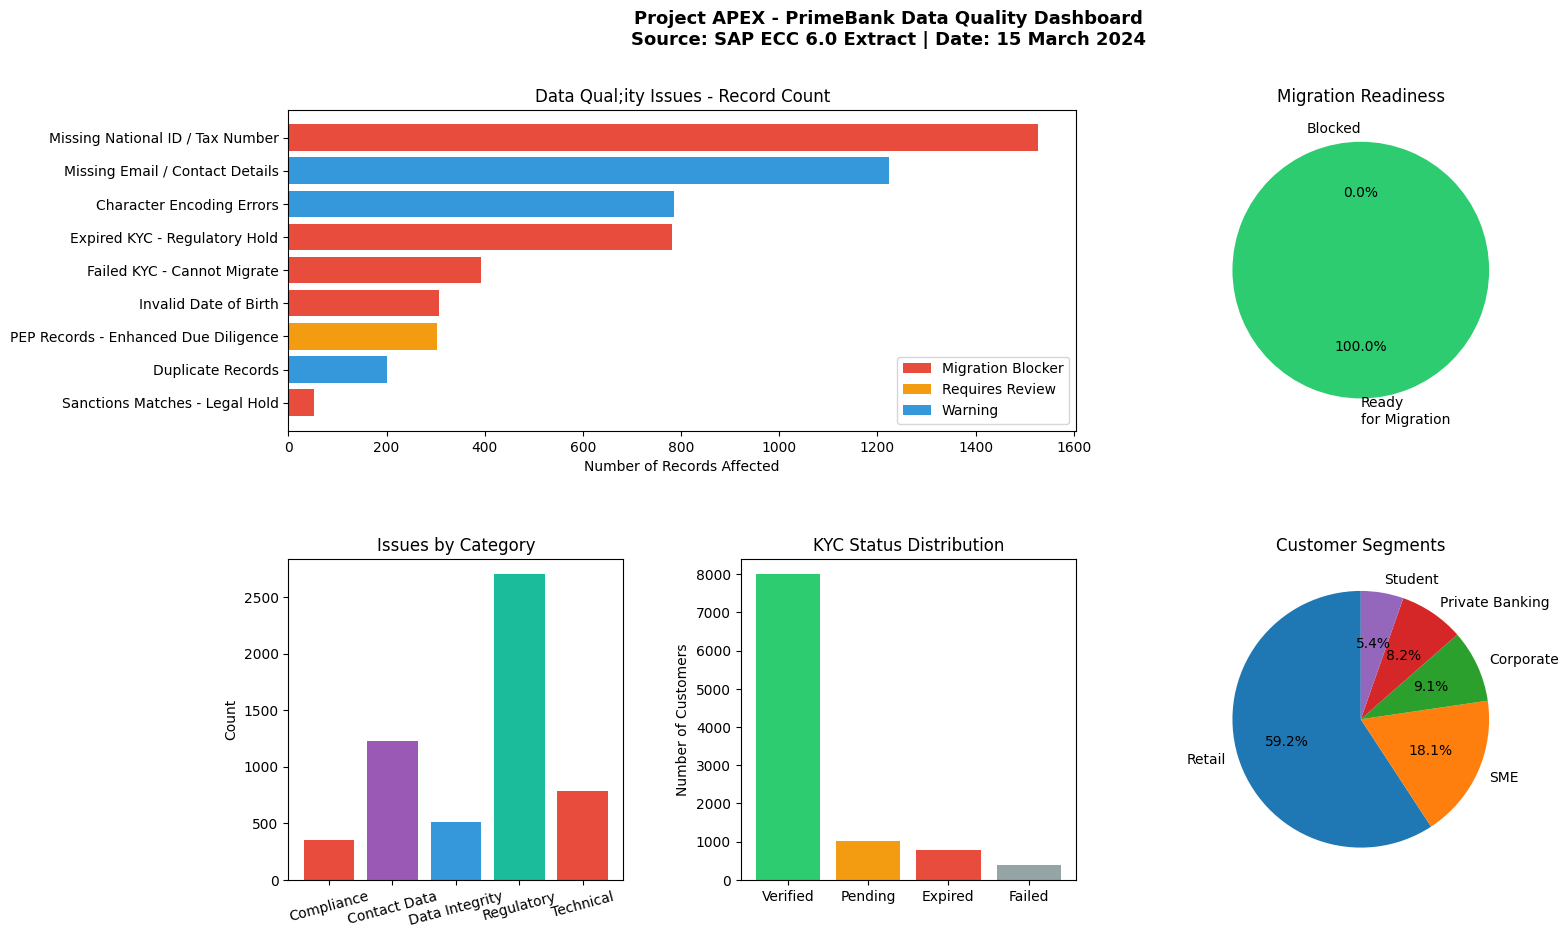

Dashboard saved as data_quality_dashboard.png


In [21]:
# Cell 5 - Visual Dashboard

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    'Project APEX - PrimeBank Data Quality Dashboard\n'
    'Source: SAP ECC 6.0 Extract | Date: 15 March 2024',
    fontsize=13, fontweight='bold'
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Chart 1: Issues by count
ax1 = fig.add_subplot(gs[0, :2])
colors_bar = [
    '#e74c3c' if imp == 'BLOCK' else
    '#f39c12' if imp == 'REVIEW' else '#3498db'
    for imp in quality_metrics.sort_values('Count')['Migration_Impact']
]
bars = ax1.barh(
    quality_metrics.sort_values('Count')['Issue'],
    quality_metrics.sort_values('Count')['Count'],
    color=colors_bar
)
ax1.set_xlabel('Number of Records Affected')
ax1.set_title('Data Qual;ity Issues - Record Count')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Migration Blocker'),
    Patch(facecolor='#f39c12', label='Requires Review'),
    Patch(facecolor='#3498db', label='Warning')
]
ax1.legend(handles=legend_elements, loc='lower right')

# Chart 2: Migration readiness pie
ax2 = fig.add_subplot(gs[0, 2])
ready = total_records - blockers
ax2.pie(
    [ready, blockers],
    labels=['Ready\nfor Migration', 'Blocked'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
ax2.set_title('Migration Readiness')

# Chart 3: Issues by category
ax3 = fig.add_subplot(gs[1, 0])
category_summary = quality_metrics.groupby('Category')['Count'].sum()
ax3.bar(category_summary.index, category_summary.values,
        color=['#e74c3c', '#9b59b6', '#3498db', '#1abc9c'])
ax3.set_title('Issues by Category')
ax3.set_ylabel('Count')
ax3.tick_params(axis='x', rotation=15)

# Chart 4: KYC status breakdown
ax4 = fig.add_subplot(gs[1, 1])
kyc_counts = customers_dirty['kyc_status'].value_counts()
ax4.bar(kyc_counts.index, kyc_counts.values,
        color=['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6'])
ax4.set_title('KYC Status Distribution')
ax4.set_ylabel('Number of Customers')

# Chart 5: Customers by segment
ax5 = fig.add_subplot(gs[1, 2])
segment_counts = customers_dirty['customer_segment'].value_counts()
ax5.pie(segment_counts.values, labels=segment_counts.index,
        autopct='%1.1f%%', startangle=90)
ax5.set_title('Customer Segments')

plt.savefig('data_quality_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as data_quality_dashboard.png")